In [194]:
from pathlib import Path

%pip install matplotlib seaborn

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

plt.style.use("default")
sns.set_theme(style="whitegrid")

ROOT = Path("../")

DADOS_PROCESSADOS = ROOT / "dados_processados"
RESULTADOS = ROOT / "resultados"

RESULTADOS.mkdir(exist_ok=True)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [195]:
base = pd.read_parquet(
    DADOS_PROCESSADOS / "base_analitica.parquet"
)

base.head()

,regiao_administrativa,nivel_geografico,tipo_crime,ano,ocorrencias,populacao,renda_per_capita,renda_domiciliar,fonte,taxa_100mil,taxa_10mil
0,Distrito Federal,Distrito Federal,homicidios,2015,619,"2,982,818.00","3,168.94","5,424.77",PDAD-A 2024,20.75,2.08
1,Águas Claras,Região Administrativa,homicidios,2015,11,"128,480.00","6,717.84","11,642.13",PDAD-A 2024,8.56,0.86
2,Arniqueira,Região Administrativa,homicidios,2015,0,"42,320.00","2,827.10","7,052.90",PDAD 2021,0.00,0.00
3,Brasília (Plano Piloto),Região Administrativa,homicidios,2015,23,"198,697.00","10,407.82","16,815.02",PDAD-A 2024,11.58,1.16
4,Brazlândia,Região Administrativa,homicidios,2015,21,"55,561.00","1,754.13","2,818.00",PDAD-A 2024,37.80,3.78


In [196]:
print("="*80)
print("INFORMAÇÕES DA BASE")
print("="*80)

print(f"Registros...............: {len(base):,}")
print(f"Colunas................: {base.shape[1]}")

print()

print(f"Período................: {base['ano'].min()} - {base['ano'].max()}")

print(f"Regiões................: {base['regiao_administrativa'].nunique()}")

print(f"Tipos de crime.........: {base['tipo_crime'].nunique()}")

print()

display(base.info())

display(base.isna().sum())

INFORMAÇÕES DA BASE
Registros...............: 1,370
Colunas................: 11

Período................: 2015 - 2024
Regiões................: 35
Tipos de crime.........: 4

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1370 entries, 0 to 1369
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   regiao_administrativa  1370 non-null   object 
 1   nivel_geografico       1370 non-null   object 
 2   tipo_crime             1370 non-null   object 
 3   ano                    1370 non-null   int64  
 4   ocorrencias            1370 non-null   int64  
 5   populacao              1360 non-null   float64
 6   renda_per_capita       1360 non-null   float64
 7   renda_domiciliar       1320 non-null   float64
 8   fonte                  1360 non-null   object 
 9   taxa_100mil            1360 non-null   float64
 10  taxa_10mil             1360 non-null   float64
dtypes: float64(5), int64(2), object(4)
mem

None

regiao_administrativa     0
nivel_geografico          0
tipo_crime                0
ano                       0
ocorrencias               0
populacao                10
renda_per_capita         10
renda_domiciliar         50
fonte                    10
taxa_100mil              10
taxa_10mil               10
dtype: int64

In [197]:
# Assinatura dos gráficos

from datetime import datetime

ANO = datetime.now().year

GITHUB = "https://github.com/gabri-eu"


def assinatura_figura(fig):
    fig.text(
        0.99,
        0.01,
        (
            f"Elaboração: Gabriel Santana ({ANO}) | "
            f"GitHub: {GITHUB}"
        ),
        ha="right",
        va="bottom",
        fontsize=9,
        style="italic",
        color="dimgray"
    )

In [198]:
estatisticas = (
    base[
        [
            "ocorrencias",
            "populacao",
            "renda_per_capita",
            "renda_domiciliar",
            "taxa_100mil",
            "taxa_10mil"
        ]
    ]
    .describe()
    .T
)

estatisticas["mediana"] = base[
    [
        "ocorrencias",
        "populacao",
        "renda_per_capita",
        "renda_domiciliar",
        "taxa_100mil",
        "taxa_10mil"
    ]
].median()

estatisticas

,count,mean,std,min,25%,50%,75%,max,mediana
ocorrencias,"1,370.00",6.47,35.89,0.00,0.00,0.00,2.00,619.00,0.00
populacao,"1,360.00","170,308.35","494,316.47","5,131.00","32,379.00","68,840.50","120,641.00","2,982,818.00","68,840.50"
renda_per_capita,"1,360.00","4,006.65","3,978.60",815.85,"1,228.20","2,783.94","4,754.06","15,780.19","2,783.94"
renda_domiciliar,"1,320.00","6,382.58","6,238.50","1,550.93","2,340.72","4,427.83","7,052.90","29,802.04","4,427.83"
taxa_100mil,"1,360.00",4.14,9.62,0.00,0.00,0.00,2.77,77.96,0.00
taxa_10mil,"1,360.00",0.41,0.96,0.00,0.00,0.00,0.28,7.80,0.00


In [199]:
# ==============================================================================
# BASES ANALÍTICAS
# ==============================================================================

base_ra = (
    base
    .loc[
        base["nivel_geografico"] == "Região Administrativa"
    ]
    .copy()
)

base_df = (
    base
    .loc[
        base["nivel_geografico"] == "Distrito Federal"
    ]
    .copy()
)

print("=" * 80)
print("BASES ANALÍTICAS")
print("=" * 80)

print(f"Base completa..................... {len(base):,}")
print(f"Regiões Administrativas........... {len(base_ra):,}")
print(f"Distrito Federal................. {len(base_df):,}")

print()

print("Regiões Administrativas:", base_ra["regiao_administrativa"].nunique())
print("Distrito Federal:", base_df["regiao_administrativa"].nunique())

BASES ANALÍTICAS
Base completa..................... 1,370
Regiões Administrativas........... 1,330
Distrito Federal................. 40

Regiões Administrativas: 34
Distrito Federal: 1


In [200]:
base_ra = (
    base
    .query("nivel_geografico == 'Região Administrativa'")
    .copy()
)

base_df = (
    base
    .query("nivel_geografico == 'Distrito Federal'")
    .copy()
)

In [201]:
base[
    [
        "ocorrencias",
        "taxa_100mil",
        "taxa_10mil"
    ]
].skew()

ocorrencias   12.26
taxa_100mil    3.72
taxa_10mil     3.72
dtype: float64

In [202]:
base[
    [
        "ocorrencias",
        "taxa_100mil",
        "taxa_10mil"
    ]
].kurtosis()

ocorrencias   169.87
taxa_100mil    16.90
taxa_10mil     16.91
dtype: float64

In [203]:
base[
    [
        "ocorrencias",
        "taxa_100mil",
        "taxa_10mil"
    ]
].quantile(
    [.01,.05,.10,.25,.50,.75,.90,.95,.99]
)

,ocorrencias,taxa_100mil,taxa_10mil
0.01,0.00,0.00,0.00
0.05,0.00,0.00,0.00
0.10,0.00,0.00,0.00
0.25,0.00,0.00,0.00
0.50,0.00,0.00,0.00
0.75,2.00,2.77,0.28
0.90,12.10,13.87,1.39
0.95,23.00,23.23,2.32
0.99,77.00,48.69,4.87


In [204]:
estatisticas_crime = (
    base
    .groupby("tipo_crime")
    .agg(
        ocorrencias_total=("ocorrencias","sum"),
        ocorrencias_media=("ocorrencias","mean"),
        ocorrencias_mediana=("ocorrencias","median"),
        ocorrencias_dp=("ocorrencias","std"),
        ocorrencias_min=("ocorrencias","min"),
        ocorrencias_max=("ocorrencias","max"),

        taxa100_media=("taxa_100mil","mean"),
        taxa100_mediana=("taxa_100mil","median"),

        taxa10_media=("taxa_10mil","mean"),

        populacao_media=("populacao","mean"),

        renda_pc_media=("renda_per_capita","mean"),

        renda_dom_media=("renda_domiciliar","mean")
    )
    .sort_values(
        "ocorrencias_total",
        ascending=False
    )
)

estatisticas_crime

,ocorrencias_total,ocorrencias_media,ocorrencias_mediana,ocorrencias_dp,ocorrencias_min,ocorrencias_max,taxa100_media,taxa100_mediana,taxa10_media,populacao_media,renda_pc_media,renda_dom_media
tipo_crime,,,,,,,,,,,,
homicidios,7720,22.06,6.00,68.40,0,619,14.41,9.66,1.44,"170,308.35","4,006.65","6,382.58"
latrocinios,574,1.69,0.00,5.31,0,47,1.11,0.00,0.11,"170,308.35","4,006.65","6,382.58"
feminicidios,452,1.33,0.00,4.02,0,33,0.90,0.00,0.09,"170,308.35","4,006.65","6,382.58"
lesao_seguida_morte,122,0.36,0.00,1.23,0,13,0.15,0.00,0.02,"170,308.35","4,006.65","6,382.58"


In [205]:
estatisticas_crime["participacao_%"] = (
    estatisticas_crime["ocorrencias_total"]
    /
    estatisticas_crime["ocorrencias_total"].sum()
)*100

estatisticas_crime

,ocorrencias_total,ocorrencias_media,ocorrencias_mediana,ocorrencias_dp,ocorrencias_min,ocorrencias_max,taxa100_media,taxa100_mediana,taxa10_media,populacao_media,renda_pc_media,renda_dom_media,participacao_%
tipo_crime,,,,,,,,,,,,,
homicidios,7720,22.06,6.00,68.40,0,619,14.41,9.66,1.44,"170,308.35","4,006.65","6,382.58",87.05
latrocinios,574,1.69,0.00,5.31,0,47,1.11,0.00,0.11,"170,308.35","4,006.65","6,382.58",6.47
feminicidios,452,1.33,0.00,4.02,0,33,0.90,0.00,0.09,"170,308.35","4,006.65","6,382.58",5.10
lesao_seguida_morte,122,0.36,0.00,1.23,0,13,0.15,0.00,0.02,"170,308.35","4,006.65","6,382.58",1.38


In [206]:
estatisticas_ra = (
    base_ra
    .groupby("regiao_administrativa")
    .agg(
        ocorrencias=("ocorrencias","sum"),

        media=("ocorrencias","mean"),

        mediana=("ocorrencias","median"),

        desvio=("ocorrencias","std"),

        taxa100=("taxa_100mil","mean"),

        taxa10=("taxa_10mil","mean"),

        populacao=("populacao","mean"),

        renda=("renda_per_capita","mean")
    )
    .sort_values(
        "ocorrencias",
        ascending=False
    )
)

estatisticas_ra

,ocorrencias,media,mediana,desvio,taxa100,taxa10,populacao,renda
regiao_administrativa,,,,,,,,
Ceilândia,711,17.77,3.00,29.84,6.19,0.62,"287,023.00","1,674.15"
Planaltina,421,10.53,2.00,18.20,5.85,0.59,"179,960.00","1,223.74"
Samambaia,370,9.25,2.00,14.55,4.23,0.42,"218,840.00","1,259.92"
Santa Maria,273,6.83,1.00,11.79,5.85,0.59,"116,622.00","1,240.49"
São Sebastião,256,6.40,1.00,10.82,6.49,0.65,"98,612.00","1,333.72"
Recanto das Emas,249,6.22,1.00,11.10,5.39,0.54,"115,550.00","1,186.44"
Gama,238,5.95,1.00,10.88,4.27,0.43,"139,467.00","3,622.43"
Taguatinga,237,5.92,2.00,8.71,3.06,0.31,"193,367.00","2,740.78"
Itapoã,197,4.92,1.00,8.06,7.53,0.75,"65,408.00","1,041.70"


In [207]:
estatisticas_ra["cv"] = (
    estatisticas_ra["desvio"]
    /
    estatisticas_ra["media"]
)

In [208]:
amplitude = (
    base_ra
    .groupby("regiao_administrativa")["ocorrencias"]
    .agg(lambda x: x.max()-x.min())
)

amplitude.sort_values(
    ascending=False
)

regiao_administrativa
Ceilândia                  112
Planaltina                  64
Santa Maria                 53
Recanto das Emas            48
Samambaia                   48
São Sebastião               40
Gama                        40
Taguatinga                  35
Paranoá                     32
Itapoã                      30
Sol Nascente/Pôr do Sol     27
Sobradinho II               24
SCIA/Estrutural             24
Brasília (Plano Piloto)     23
Brazlândia                  21
Sobradinho                  20
Guará                       15
Riacho Fundo II             12
Águas Claras                11
Vicente Pires                8
Fercal                       7
Candangolândia               6
Arniqueira                   6
Riacho Fundo                 5
Lago Norte                   5
Unidades Prisionais          5
SIA                          4
Varjão                       4
Núcleo Bandeirante           3
Park Way                     2
Lago Sul                     2
Sudoeste/Octogona

In [209]:
ranking_ocorrencias = (
    estatisticas_ra
    .sort_values(
        "ocorrencias",
        ascending=False
    )
)

ranking_ocorrencias.head(15)

,ocorrencias,media,mediana,desvio,taxa100,taxa10,populacao,renda,cv
regiao_administrativa,,,,,,,,,
Ceilândia,711,17.77,3.00,29.84,6.19,0.62,"287,023.00","1,674.15",1.68
Planaltina,421,10.53,2.00,18.20,5.85,0.59,"179,960.00","1,223.74",1.73
Samambaia,370,9.25,2.00,14.55,4.23,0.42,"218,840.00","1,259.92",1.57
Santa Maria,273,6.83,1.00,11.79,5.85,0.59,"116,622.00","1,240.49",1.73
São Sebastião,256,6.40,1.00,10.82,6.49,0.65,"98,612.00","1,333.72",1.69
Recanto das Emas,249,6.22,1.00,11.10,5.39,0.54,"115,550.00","1,186.44",1.78
Gama,238,5.95,1.00,10.88,4.27,0.43,"139,467.00","3,622.43",1.83
Taguatinga,237,5.92,2.00,8.71,3.06,0.31,"193,367.00","2,740.78",1.47
Itapoã,197,4.92,1.00,8.06,7.53,0.75,"65,408.00","1,041.70",1.64


In [210]:
ranking_taxa100 = (
    estatisticas_ra
    .sort_values(
        "taxa100",
        ascending=False
    )
)

ranking_taxa100.head(15)

,ocorrencias,media,mediana,desvio,taxa100,taxa10,populacao,renda,cv
regiao_administrativa,,,,,,,,,
SIA,27,0.68,0.00,1.23,13.16,1.32,"5,131.00","1,183.63",1.82
SCIA/Estrutural,179,4.47,1.00,7.51,12.42,1.24,"36,042.00",815.85,1.68
Fercal,49,1.23,0.00,1.87,11.93,1.19,"10,268.00",959.90,1.53
Itapoã,197,4.92,1.00,8.06,7.53,0.75,"65,408.00","1,041.70",1.64
São Sebastião,256,6.40,1.00,10.82,6.49,0.65,"98,612.00","1,333.72",1.69
Paranoá,165,4.12,0.50,7.25,6.45,0.65,"63,923.00","1,059.70",1.76
Ceilândia,711,17.77,3.00,29.84,6.19,0.62,"287,023.00","1,674.15",1.68
Santa Maria,273,6.83,1.00,11.79,5.85,0.59,"116,622.00","1,240.49",1.73
Planaltina,421,10.53,2.00,18.20,5.85,0.59,"179,960.00","1,223.74",1.73


In [211]:
ranking_pop = (
    estatisticas_ra
    .sort_values(
        "populacao",
        ascending=False
    )
)

ranking_pop.head(15)

,ocorrencias,media,mediana,desvio,taxa100,taxa10,populacao,renda,cv
regiao_administrativa,,,,,,,,,
Ceilândia,711,17.77,3.00,29.84,6.19,0.62,"287,023.00","1,674.15",1.68
Samambaia,370,9.25,2.00,14.55,4.23,0.42,"218,840.00","1,259.92",1.57
Brasília (Plano Piloto),147,3.67,1.00,5.92,1.85,0.18,"198,697.00","10,407.82",1.61
Taguatinga,237,5.92,2.00,8.71,3.06,0.31,"193,367.00","2,740.78",1.47
Planaltina,421,10.53,2.00,18.20,5.85,0.59,"179,960.00","1,223.74",1.73
Gama,238,5.95,1.00,10.88,4.27,0.43,"139,467.00","3,622.43",1.83
Águas Claras,48,1.20,0.00,2.48,0.93,0.09,"128,480.00","6,717.84",2.07
Guará,59,1.48,0.00,2.88,1.22,0.12,"120,641.00","4,754.06",1.95
Santa Maria,273,6.83,1.00,11.79,5.85,0.59,"116,622.00","1,240.49",1.73


In [212]:
ranking_renda = (
    estatisticas_ra
    .sort_values(
        "renda",
        ascending=False
    )
)

ranking_renda.head(15)

,ocorrencias,media,mediana,desvio,taxa100,taxa10,populacao,renda,cv
regiao_administrativa,,,,,,,,,
Lago Sul,8,0.20,0.00,0.46,0.76,0.08,"26,244.00","15,780.19",2.32
Sudoeste/Octogonal,10,0.25,0.00,0.54,0.56,0.06,"44,354.00","15,444.99",2.17
Lago Norte,19,0.47,0.00,0.99,1.47,0.15,"32,379.00","11,603.22",2.08
Brasília (Plano Piloto),147,3.67,1.00,5.92,1.85,0.18,"198,697.00","10,407.82",1.61
Park Way,10,0.25,0.00,0.49,1.12,0.11,"22,289.00","8,806.14",1.97
Jardim Botânico,4,0.10,0.00,0.30,0.13,0.01,"77,707.00","7,286.55",3.04
Águas Claras,48,1.20,0.00,2.48,0.93,0.09,"128,480.00","6,717.84",2.07
Cruzeiro,11,0.28,0.00,0.60,1.07,0.11,"25,741.00","4,868.60",2.18
Guará,59,1.48,0.00,2.88,1.22,0.12,"120,641.00","4,754.06",1.95


In [213]:
base_ra["tipo_crime"].value_counts()

tipo_crime
homicidios             340
latrocinios            330
lesao_seguida_morte    330
feminicidios           330
Name: count, dtype: int64

In [214]:
base_ra["regiao_administrativa"].value_counts()

regiao_administrativa
Águas Claras               40
SIA                        40
Riacho Fundo               40
Riacho Fundo II            40
Samambaia                  40
Santa Maria                40
São Sebastião              40
SCIA/Estrutural            40
Sobradinho                 40
Arniqueira                 40
Sobradinho II              40
Sol Nascente/Pôr do Sol    40
Sudoeste/Octogonal         40
Taguatinga                 40
Varjão                     40
Vicente Pires              40
Recanto das Emas           40
Planaltina                 40
Park Way                   40
Paranoá                    40
Núcleo Bandeirante         40
Lago Sul                   40
Lago Norte                 40
Jardim Botânico            40
Itapoã                     40
Guará                      40
Gama                       40
Fercal                     40
Cruzeiro                   40
Ceilândia                  40
Candangolândia             40
Brazlândia                 40
Brasília (Plano Pi

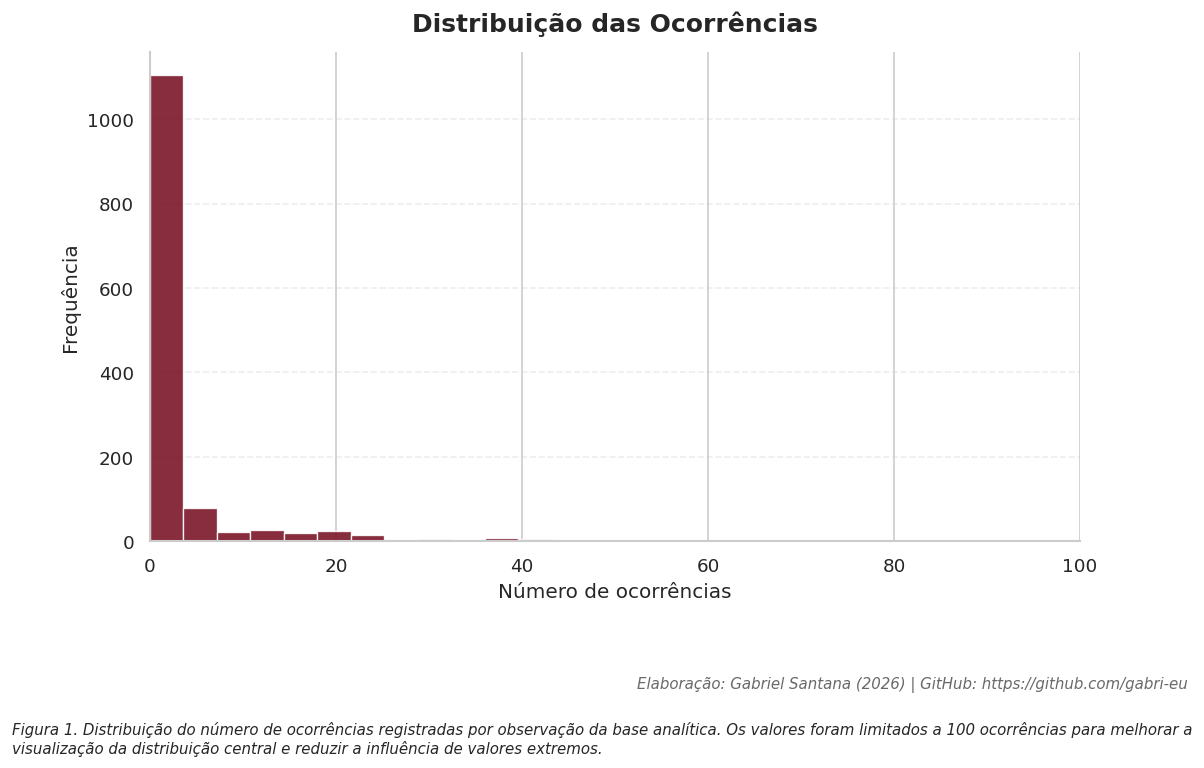

In [215]:
# ==============================================================================
# Figura 1 — Distribuição das Ocorrências
# ==============================================================================

limite = 100

dados = (
    base_ra.loc[
        base_ra["ocorrencias"] <= limite,
        "ocorrencias"
    ]
)

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

ax.hist(
    dados,
    bins=25,
    color="#7A1628",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.90
)

ax.set_xlim(0, limite)

ax.set_title(
    "Distribuição das Ocorrências",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Número de ocorrências", fontsize=12)
ax.set_ylabel("Frequência", fontsize=12)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    -0.03,
    (
        "Figura 1. Distribuição do número de ocorrências registradas por observação da base analítica. "
        "Os valores foram limitados a 100 ocorrências para melhorar a visualização da distribuição central "
        "e reduzir a influência de valores extremos."
    ),
    ha="left",
    va="top",
    fontsize=9,
    style="italic",
    wrap=True
)

assinatura_figura(fig)

plt.subplots_adjust(
    bottom=0.22,
    top=0.90
)

plt.show()

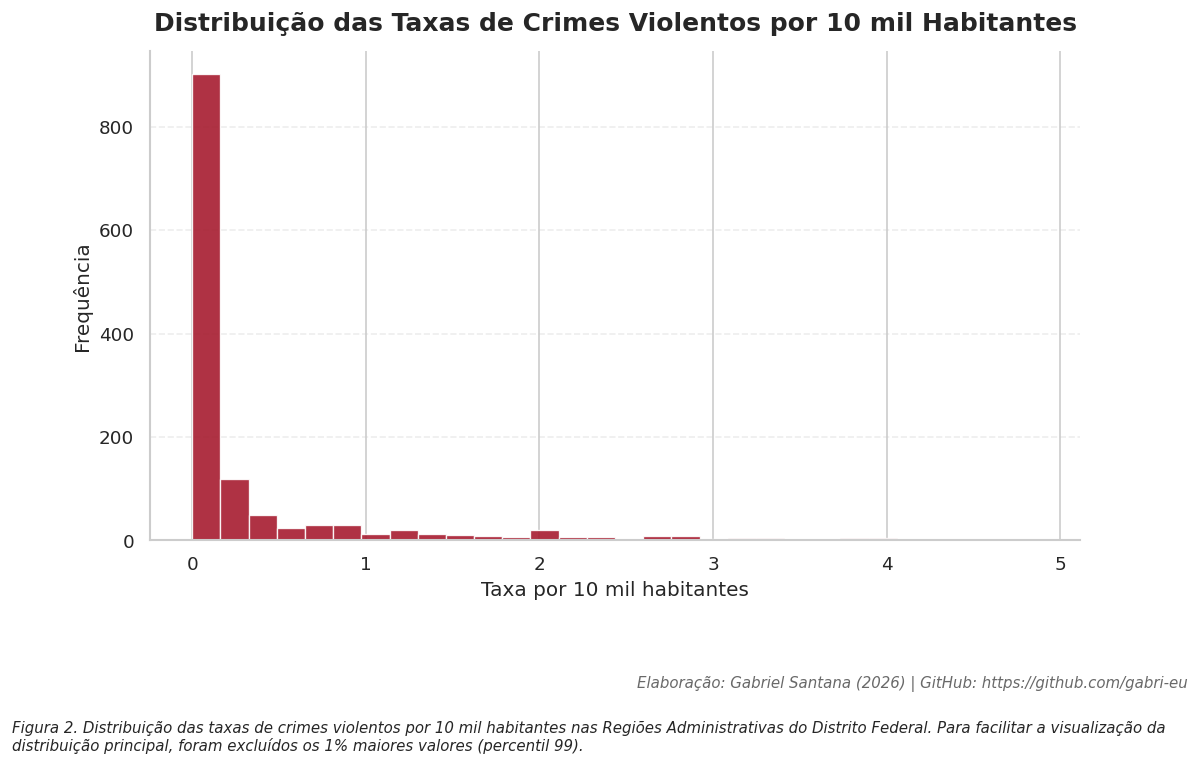

In [222]:
# ==============================================================================
# Figura 2 — Distribuição das Taxas de Crimes Violentos
# ==============================================================================

limite = base_ra["taxa_10mil"].quantile(0.99)

dados = (
    base_ra.loc[
        base_ra["taxa_10mil"] <= limite,
        "taxa_10mil"
    ]
)

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

ax.hist(
    dados,
    bins=30,
    color="#A61C2F",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.90
)

ax.set_title(
    "Distribuição das Taxas de Crimes Violentos por 10 mil Habitantes",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Taxa por 10 mil habitantes", fontsize=12)
ax.set_ylabel("Frequência", fontsize=12)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    -0.03,
    (
        "Figura 2. Distribuição das taxas de crimes violentos por 10 mil habitantes nas "
        "Regiões Administrativas do Distrito Federal. Para facilitar a visualização da "
        "distribuição principal, foram excluídos os 1% maiores valores (percentil 99)."
    ),
    ha="left",
    va="top",
    fontsize=9,
    style="italic",
    wrap=True
)

assinatura_figura(fig)

plt.subplots_adjust(
    bottom=0.22,
    top=0.90
)

plt.show()

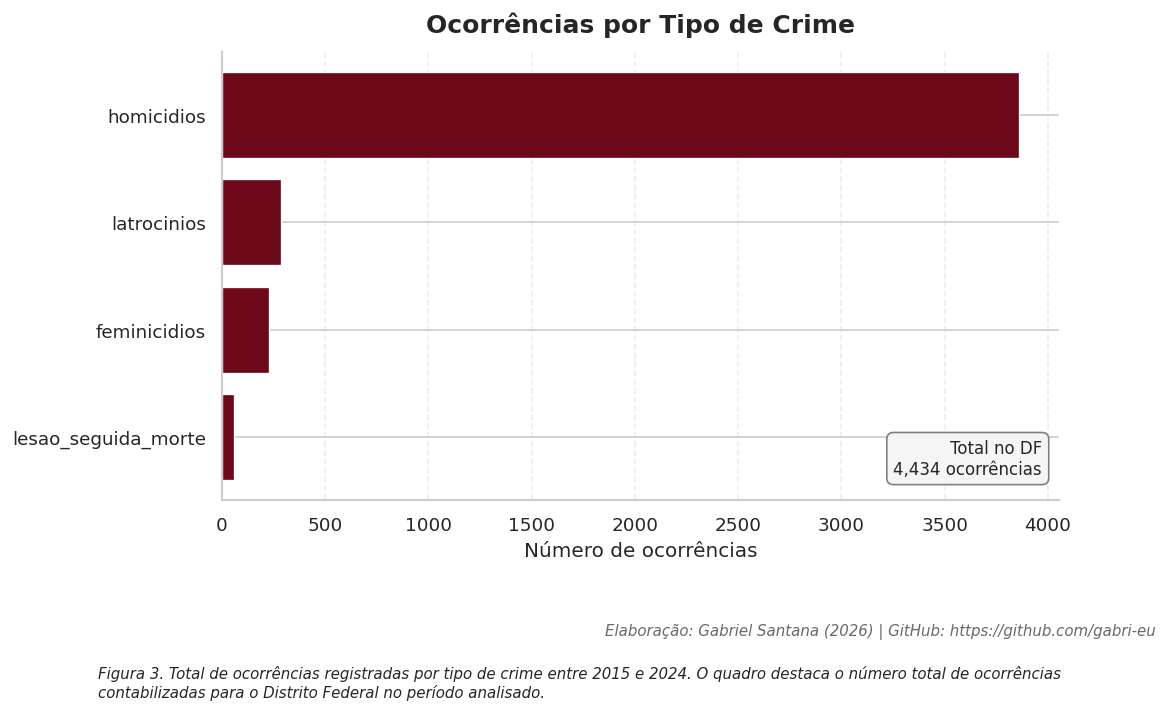

In [223]:
# ==============================================================================
# Figura 3 — Ocorrências por Tipo de Crime
# ==============================================================================

crime = (
    base_ra
    .groupby("tipo_crime")["ocorrencias"]
    .sum()
    .sort_values(ascending=True)
)

total_df = (
    base_df["ocorrencias"]
    .sum()
)

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=120)

ax.barh(
    crime.index,
    crime.values,
    color="#6D071A",
    edgecolor="white",
    linewidth=0.8
)

ax.set_title(
    "Ocorrências por Tipo de Crime",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Número de ocorrências", fontsize=12)
ax.set_ylabel("")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Resumo do DF
ax.text(
    0.98,
    0.05,
    f"Total no DF\n{total_df:,} ocorrências",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox=dict(
        facecolor="#F5F5F5",
        edgecolor="gray",
        boxstyle="round,pad=0.4"
    )
)

fig.text(
    0.01,
    -0.03,
    (
        "Figura 3. Total de ocorrências registradas por tipo de crime entre 2015 e 2024. "
        "O quadro destaca o número total de ocorrências contabilizadas para o Distrito Federal "
        "no período analisado."
    ),
    ha="left",
    va="top",
    fontsize=9,
    style="italic",
    wrap=True
)

assinatura_figura(fig)

plt.subplots_adjust(
    bottom=0.22,
    top=0.90
)

plt.show()

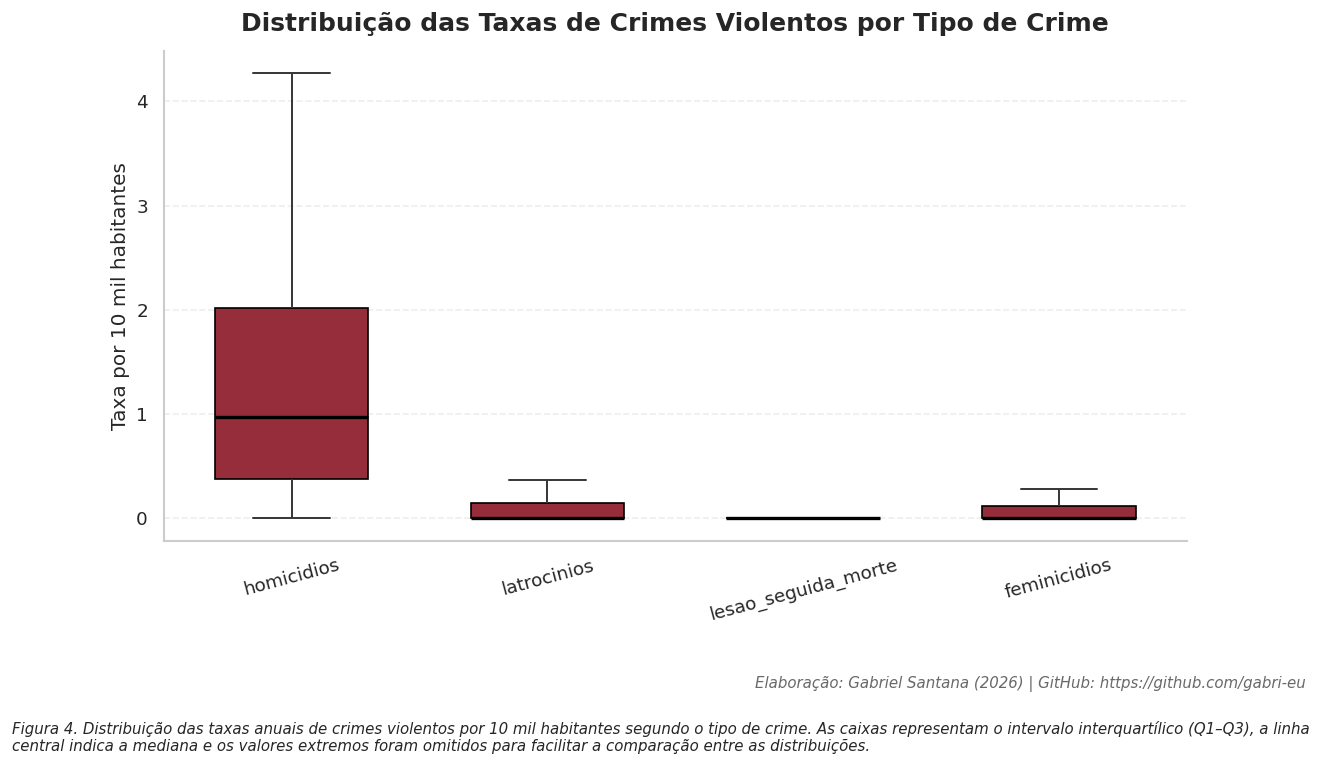

In [224]:
# ==============================================================================
# Figura 4 — Distribuição das Taxas por Tipo de Crime
# ==============================================================================

fig, ax = plt.subplots(figsize=(11, 6), dpi=120)

sns.boxplot(
    data=base_ra,
    x="tipo_crime",
    y="taxa_10mil",
    showfliers=False,
    width=0.6,
    color="#A61C2F",
    medianprops={
        "color": "black",
        "linewidth": 2
    },
    whiskerprops={
        "linewidth": 1.2
    },
    capprops={
        "linewidth": 1.2
    },
    boxprops={
        "edgecolor": "black"
    },
    ax=ax
)

ax.set_title(
    "Distribuição das Taxas de Crimes Violentos por Tipo de Crime",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("")
ax.set_ylabel("Taxa por 10 mil habitantes", fontsize=12)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=15)

fig.text(
    0.01,
    -0.03,
    (
        "Figura 4. Distribuição das taxas anuais de crimes violentos por 10 mil habitantes "
        "segundo o tipo de crime. As caixas representam o intervalo interquartílico (Q1–Q3), "
        "a linha central indica a mediana e os valores extremos foram omitidos para facilitar a comparação entre as distribuições."
    ),
    ha="left",
    va="top",
    fontsize=9,
    style="italic",
    wrap=True
)

assinatura_figura(fig)

plt.subplots_adjust(
    bottom=0.22,
    top=0.90
)

plt.show()

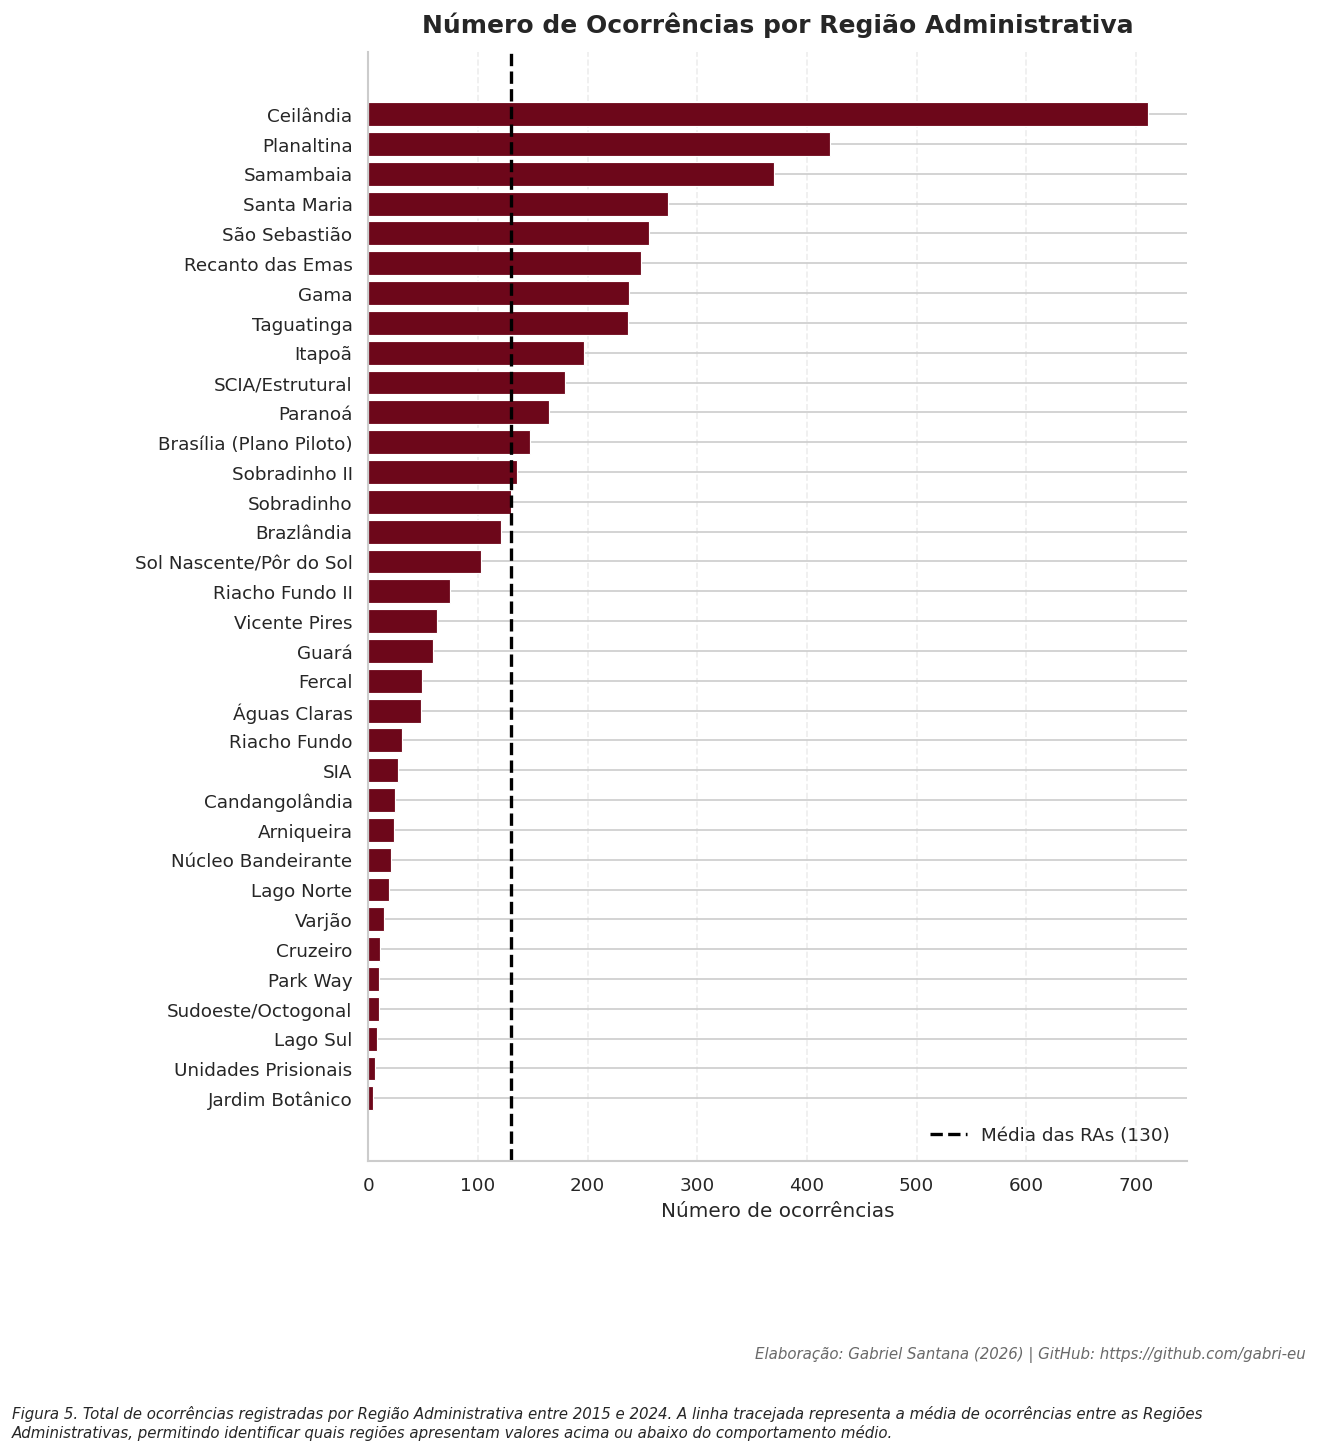

In [225]:
# ==============================================================================
# Figura 5 — Ocorrências por Região Administrativa
# ==============================================================================

ranking = (
    base_ra
    .groupby("regiao_administrativa")["ocorrencias"]
    .sum()
    .sort_values(ascending=True)
)

media_df = ranking.mean()

fig, ax = plt.subplots(figsize=(11, 12), dpi=120)

ax.barh(
    ranking.index,
    ranking.values,
    color="#6D071A",
    edgecolor="white",
    linewidth=0.7
)

ax.axvline(
    media_df,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Média das RAs ({media_df:.0f})"
)

ax.set_title(
    "Número de Ocorrências por Região Administrativa",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Número de ocorrências", fontsize=12)
ax.set_ylabel("")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="lower right"
)

fig.text(
    0.01,
    -0.02,
    (
        "Figura 5. Total de ocorrências registradas por Região Administrativa entre 2015 e 2024. "
        "A linha tracejada representa a média de ocorrências entre as Regiões Administrativas, "
        "permitindo identificar quais regiões apresentam valores acima ou abaixo do comportamento médio."
    ),
    ha="left",
    va="top",
    fontsize=9,
    style="italic",
    wrap=True
)

assinatura_figura(fig)

plt.subplots_adjust(
    left=0.28,
    bottom=0.15,
    top=0.92
)

plt.show()

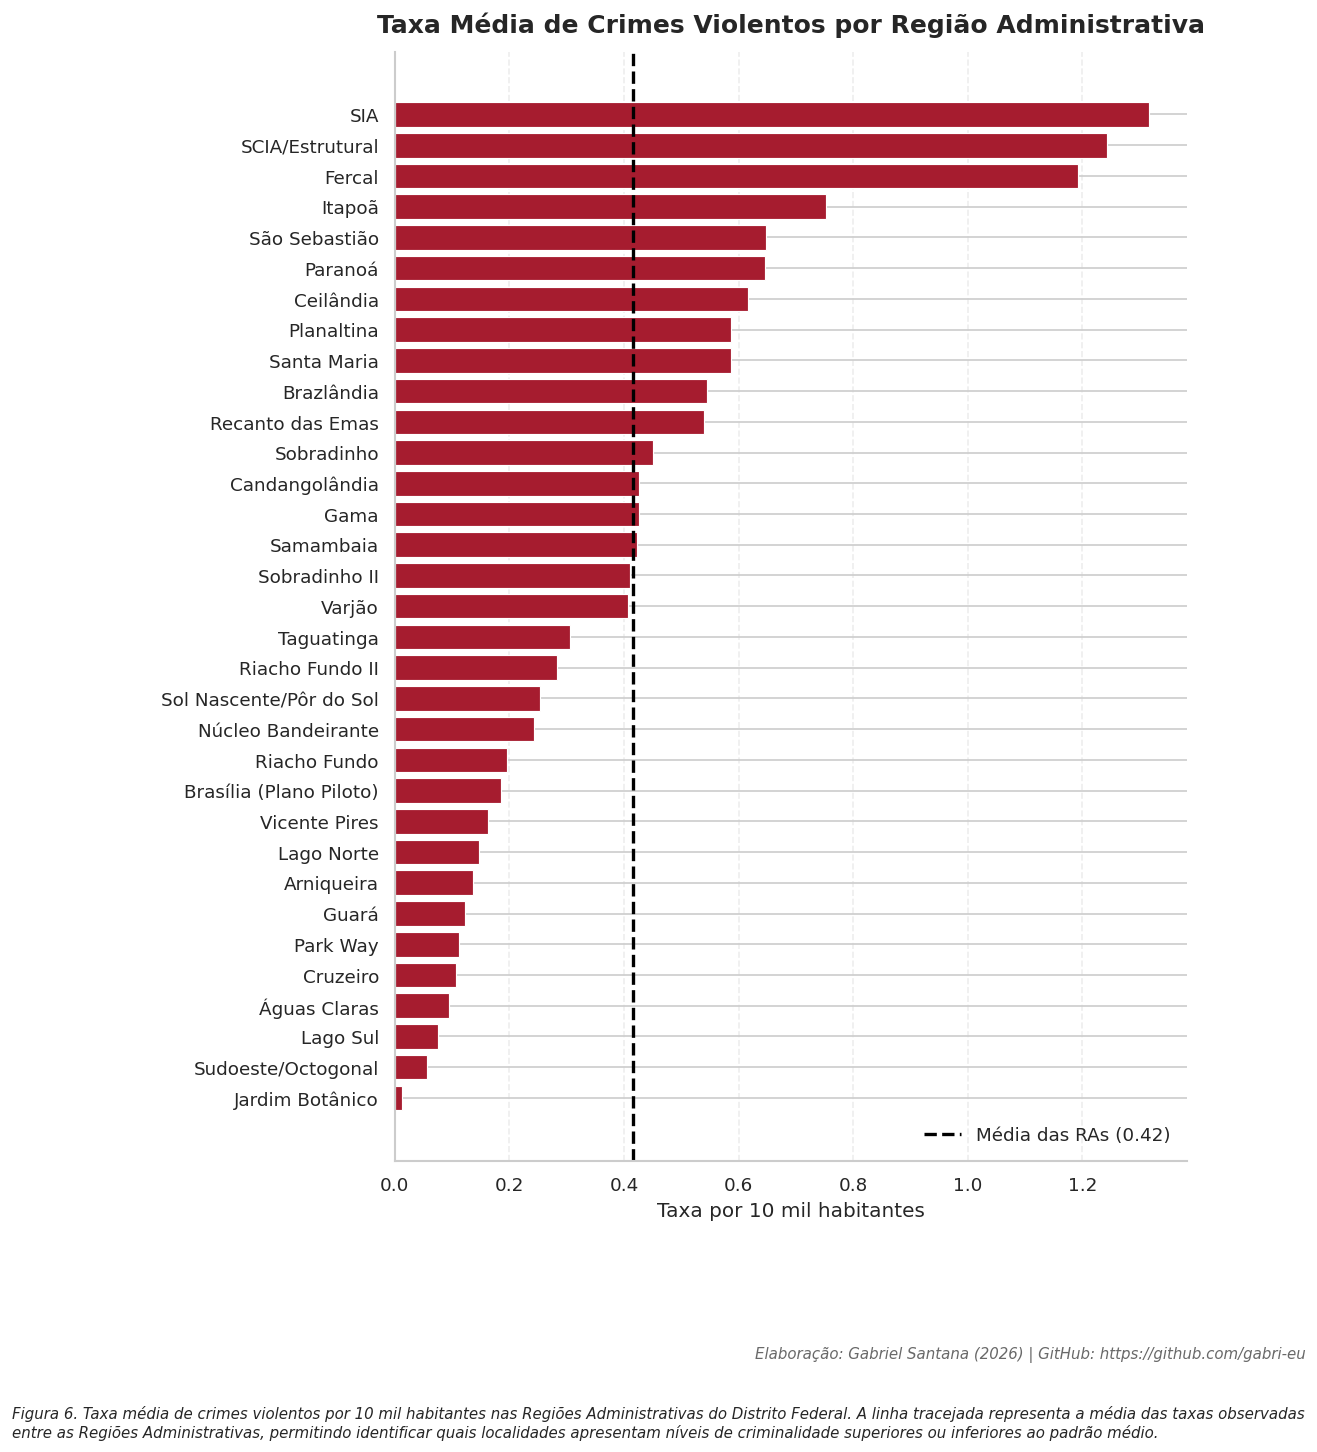

In [226]:
# ==============================================================================
# Figura 6 — Taxa Média de Crimes Violentos por Região Administrativa
# ==============================================================================

ranking = (
    base_ra
    .loc[
        base_ra["regiao_administrativa"] != "Unidades Prisionais"
    ]
    .groupby("regiao_administrativa")["taxa_10mil"]
    .mean()
    .sort_values()
)

media_ra = ranking.mean()

fig, ax = plt.subplots(figsize=(11, 12), dpi=120)

ax.barh(
    ranking.index,
    ranking.values,
    color="#A61C2F",
    edgecolor="white",
    linewidth=0.7
)

ax.axvline(
    media_ra,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Média das RAs ({media_ra:.2f})"
)

ax.set_title(
    "Taxa Média de Crimes Violentos por Região Administrativa",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Taxa por 10 mil habitantes", fontsize=12)
ax.set_ylabel("")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="lower right"
)

fig.text(
    0.01,
    -0.02,
    (
        "Figura 6. Taxa média de crimes violentos por 10 mil habitantes nas Regiões "
        "Administrativas do Distrito Federal. A linha tracejada representa a média das "
        "taxas observadas entre as Regiões Administrativas, permitindo identificar quais "
        "localidades apresentam níveis de criminalidade superiores ou inferiores ao padrão médio."
    ),
    ha="left",
    va="top",
    fontsize=9,
    style="italic",
    wrap=True
)

assinatura_figura(fig)

plt.subplots_adjust(
    left=0.30,
    bottom=0.15,
    top=0.92
)

plt.show()

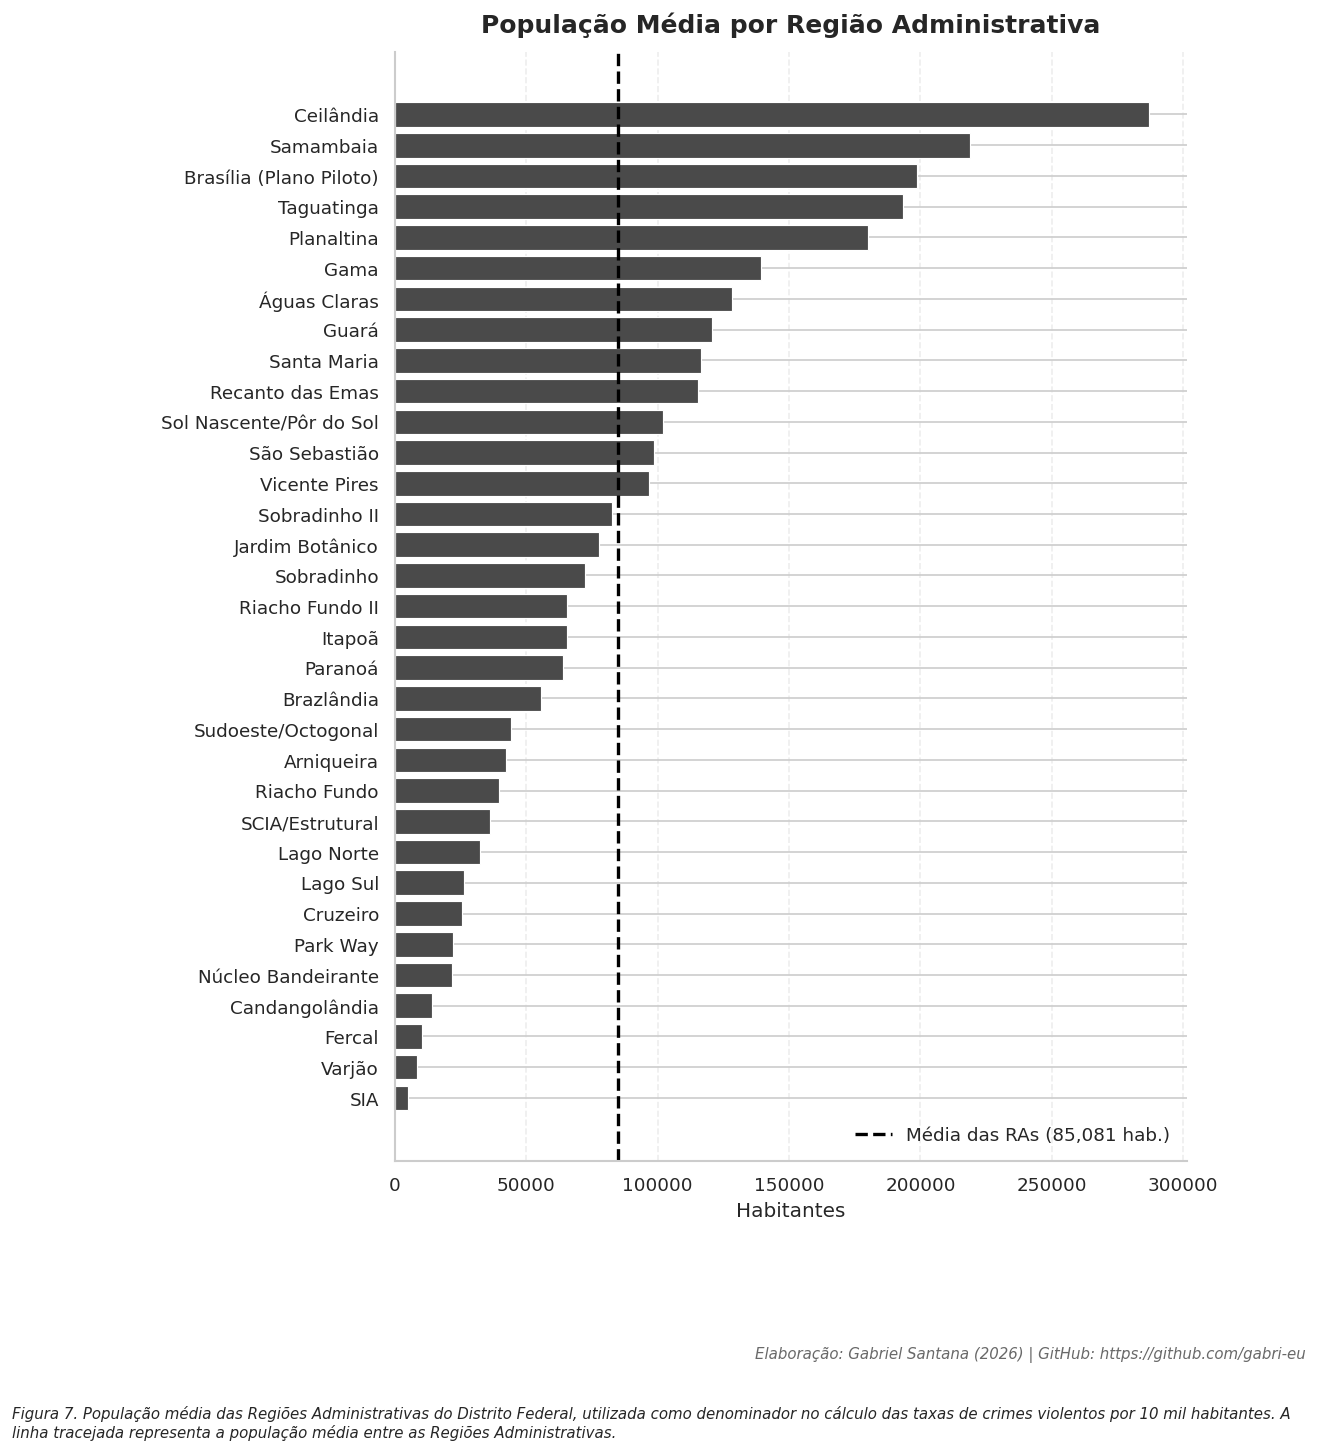

In [227]:
# ==============================================================================
# Figura 7 — População por Região Administrativa
# ==============================================================================

ranking = (
    base_ra
    .loc[
        base_ra["regiao_administrativa"] != "Unidades Prisionais"
    ]
    .groupby("regiao_administrativa")["populacao"]
    .mean()
    .sort_values()
)

media_ra = ranking.mean()

fig, ax = plt.subplots(figsize=(11, 12), dpi=120)

ax.barh(
    ranking.index,
    ranking.values,
    color="#4A4A4A",
    edgecolor="white",
    linewidth=0.7
)

ax.axvline(
    media_ra,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Média das RAs ({media_ra:,.0f} hab.)"
)

ax.set_title(
    "População Média por Região Administrativa",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Habitantes", fontsize=12)
ax.set_ylabel("")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="lower right"
)

fig.text(
    0.01,
    -0.02,
    (
        "Figura 7. População média das Regiões Administrativas do Distrito Federal, "
        "utilizada como denominador no cálculo das taxas de crimes violentos por "
        "10 mil habitantes. A linha tracejada representa a população média entre as "
        "Regiões Administrativas."
    ),
    ha="left",
    va="top",
    fontsize=9,
    style="italic",
    wrap=True
)

assinatura_figura(fig)

plt.subplots_adjust(
    left=0.30,
    bottom=0.15,
    top=0.92
)

plt.show()

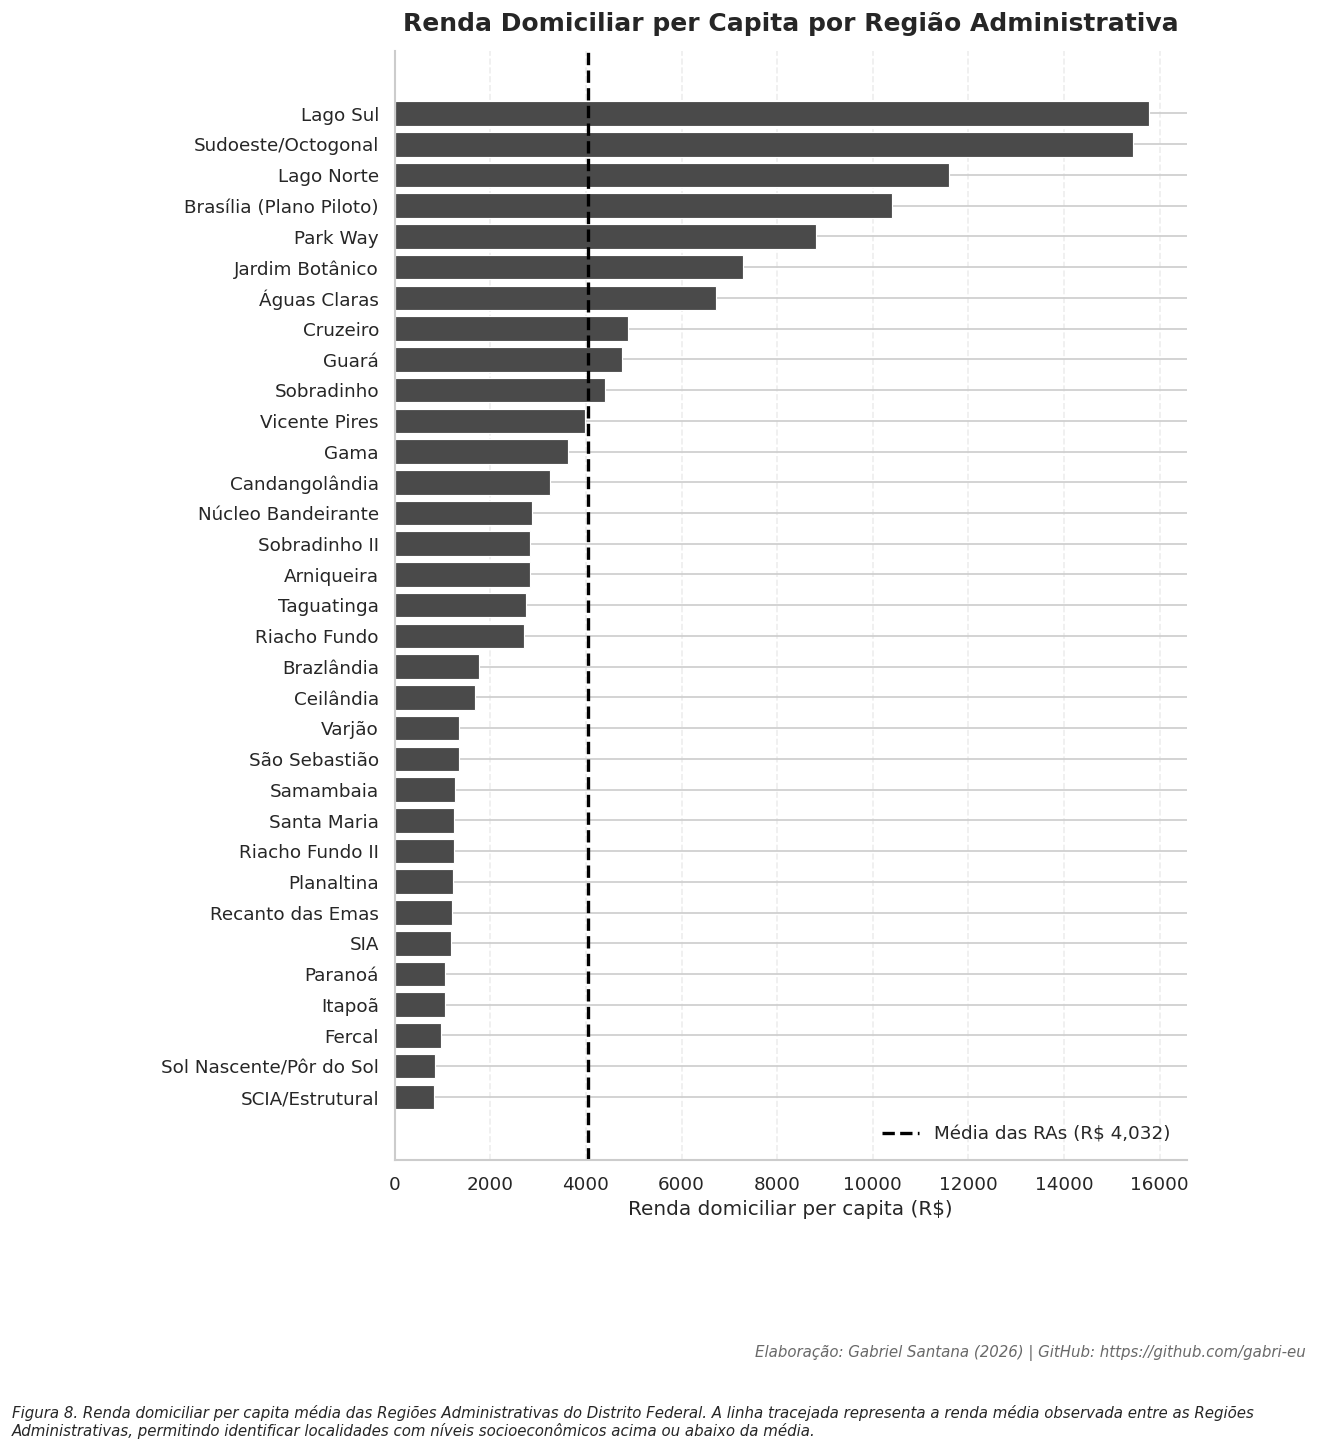

In [228]:
# ==============================================================================
# Figura 8 — Renda Domiciliar per Capita por Região Administrativa
# ==============================================================================

ranking = (
    base_ra
    .loc[
        base_ra["regiao_administrativa"] != "Unidades Prisionais"
    ]
    .groupby("regiao_administrativa")["renda_per_capita"]
    .mean()
    .sort_values()
)

media_ra = ranking.mean()

fig, ax = plt.subplots(figsize=(11, 12), dpi=120)

ax.barh(
    ranking.index,
    ranking.values,
    color="#4A4A4A",
    edgecolor="white",
    linewidth=0.7
)

ax.axvline(
    media_ra,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Média das RAs (R$ {media_ra:,.0f})"
)

ax.set_title(
    "Renda Domiciliar per Capita por Região Administrativa",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Renda domiciliar per capita (R$)", fontsize=12)
ax.set_ylabel("")

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="lower right"
)

fig.text(
    0.01,
    -0.02,
    (
        "Figura 8. Renda domiciliar per capita média das Regiões Administrativas do "
        "Distrito Federal. A linha tracejada representa a renda média observada entre "
        "as Regiões Administrativas, permitindo identificar localidades com níveis "
        "socioeconômicos acima ou abaixo da média."
    ),
    ha="left",
    va="top",
    fontsize=9,
    style="italic",
    wrap=True
)

assinatura_figura(fig)

plt.subplots_adjust(
    left=0.30,
    bottom=0.15,
    top=0.92
)

plt.show()

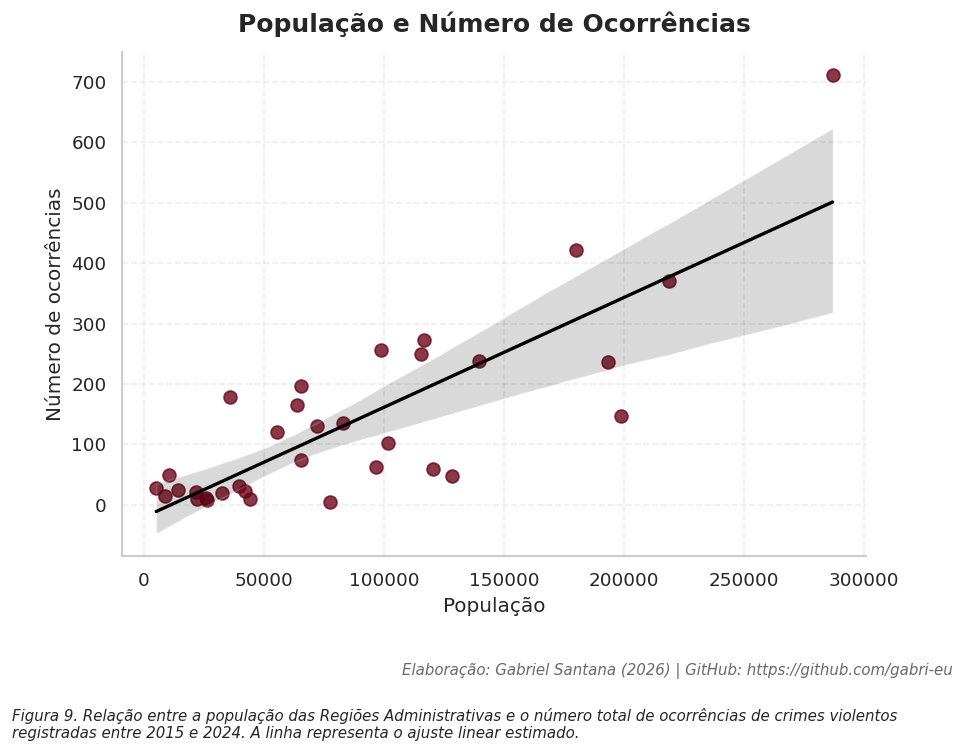

In [229]:
# ==============================================================================
# Figura 9 — População e Ocorrências
# ==============================================================================

dados = (
    base_ra
    .loc[
        base_ra["regiao_administrativa"] != "Unidades Prisionais"
    ]
    .groupby("regiao_administrativa", as_index=False)
    .agg(
        populacao=("populacao", "mean"),
        ocorrencias=("ocorrencias", "sum")
    )
)

fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

sns.regplot(
    data=dados,
    x="populacao",
    y="ocorrencias",
    scatter_kws={
        "s": 60,
        "color": "#6D071A",
        "alpha": 0.80
    },
    line_kws={
        "color": "black",
        "linewidth": 2
    },
    ax=ax
)

ax.set_title(
    "População e Número de Ocorrências",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("População")
ax.set_ylabel("Número de ocorrências")

ax.grid(
    linestyle="--",
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    -0.03,
    (
        "Figura 9. Relação entre a população das Regiões Administrativas e o número "
        "total de ocorrências de crimes violentos registradas entre 2015 e 2024. "
        "A linha representa o ajuste linear estimado."
    ),
    ha="left",
    va="top",
    fontsize=9,
    style="italic",
    wrap=True
)

assinatura_figura(fig)

plt.subplots_adjust(bottom=0.18)

plt.show()

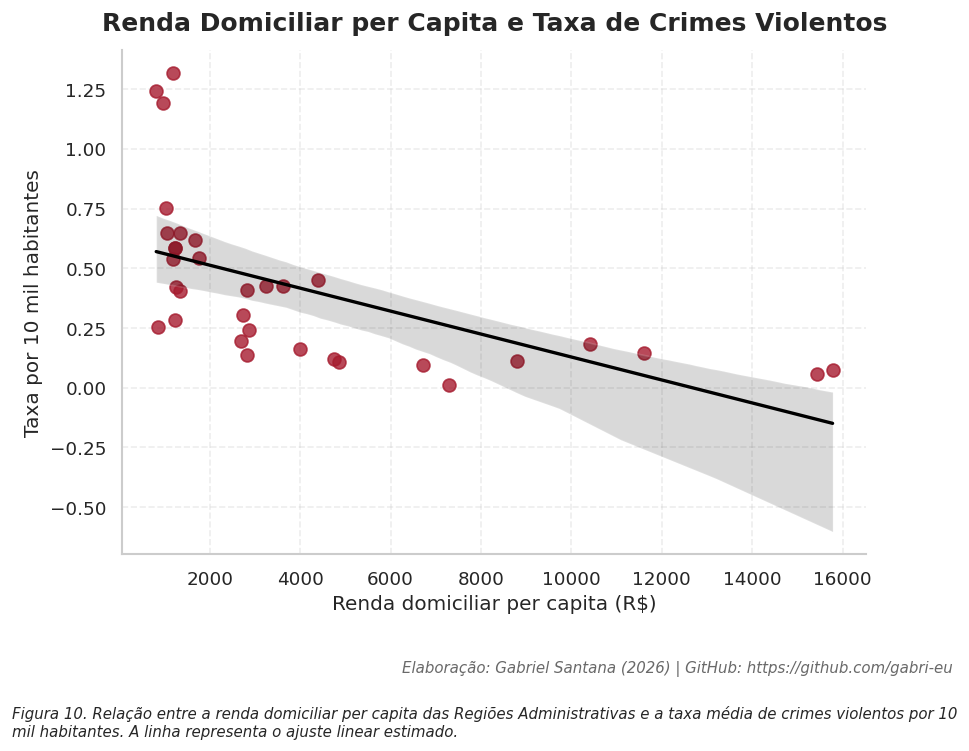

In [230]:
# ==============================================================================
# Figura 10 — Renda per Capita e Taxa de Crimes Violentos
# ==============================================================================

dados = (
    base_ra
    .loc[
        base_ra["regiao_administrativa"] != "Unidades Prisionais"
    ]
    .groupby("regiao_administrativa", as_index=False)
    .agg(
        renda=("renda_per_capita", "mean"),
        taxa=("taxa_10mil", "mean")
    )
)

fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

sns.regplot(
    data=dados,
    x="renda",
    y="taxa",
    scatter_kws={
        "s": 60,
        "color": "#A61C2F",
        "alpha": 0.80
    },
    line_kws={
        "color": "black",
        "linewidth": 2
    },
    ax=ax
)

ax.set_title(
    "Renda Domiciliar per Capita e Taxa de Crimes Violentos",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Renda domiciliar per capita (R$)")
ax.set_ylabel("Taxa por 10 mil habitantes")

ax.grid(
    linestyle="--",
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    -0.03,
    (
        "Figura 10. Relação entre a renda domiciliar per capita das Regiões "
        "Administrativas e a taxa média de crimes violentos por 10 mil habitantes. "
        "A linha representa o ajuste linear estimado."
    ),
    ha="left",
    va="top",
    fontsize=9,
    style="italic",
    wrap=True
)

assinatura_figura(fig)

plt.subplots_adjust(bottom=0.18)

plt.show()

In [221]:
estatisticas.to_csv(
    RESULTADOS / "estatisticas_gerais.csv",
    encoding="utf-8-sig"
)

estatisticas_crime.to_csv(
    RESULTADOS / "estatisticas_tipo_crime.csv",
    encoding="utf-8-sig"
)

estatisticas_ra.to_csv(
    RESULTADOS / "estatisticas_regioes.csv",
    encoding="utf-8-sig"
)

ranking_ocorrencias.to_csv(
    RESULTADOS / "ranking_ocorrencias.csv",
    encoding="utf-8-sig"
)

ranking_taxa100.to_csv(
    RESULTADOS / "ranking_taxa100.csv",
    encoding="utf-8-sig"
)